### Required Assignment 5.1: Will the Customer Accept the Coupon?

**Context**

Imagine driving through town and a coupon is delivered to your cell phone for a restaurant near where you are driving. Would you accept that coupon and take a short detour to the restaurant? Would you accept the coupon but use it on a subsequent trip? Would you ignore the coupon entirely? What if the coupon was for a bar instead of a restaurant? What about a coffee house? Would you accept a bar coupon with a minor passenger in the car? What about if it was just you and your partner in the car? Would weather impact the rate of acceptance? What about the time of day?

Obviously, proximity to the business is a factor on whether the coupon is delivered to the driver or not, but what are the factors that determine whether a driver accepts the coupon once it is delivered to them? How would you determine whether a driver is likely to accept a coupon?

**Overview**

The goal of this project is to use what you know about visualizations and probability distributions to distinguish between customers who accepted a driving coupon versus those that did not.

**Data**

This data comes to us from the UCI Machine Learning repository and was collected via a survey on Amazon Mechanical Turk. The survey describes different driving scenarios including the destination, current time, weather, passenger, etc., and then ask the person whether he will accept the coupon if he is the driver. Answers that the user will drive there ‘right away’ or ‘later before the coupon expires’ are labeled as ‘Y = 1’ and answers ‘no, I do not want the coupon’ are labeled as ‘Y = 0’.  There are five different types of coupons -- less expensive restaurants (under \$20), coffee houses, carry out & take away, bar, and more expensive restaurants (\$20 - $50).

**Deliverables**

Your final product should be a brief report that highlights the differences between customers who did and did not accept the coupons.  To explore the data you will utilize your knowledge of plotting, statistical summaries, and visualization using Python. You will publish your findings in a public facing github repository as your first portfolio piece.





### Data Description
Keep in mind that these values mentioned below are average values.

The attributes of this data set include:
1. User attributes
    -  Gender: male, female
    -  Age: below 21, 21 to 25, 26 to 30, etc.
    -  Marital Status: single, married partner, unmarried partner, or widowed
    -  Number of children: 0, 1, or more than 1
    -  Education: high school, bachelors degree, associates degree, or graduate degree
    -  Occupation: architecture & engineering, business & financial, etc.
    -  Annual income: less than \\$12500, \\$12500 - \\$24999, \\$25000 - \\$37499, etc.
    -  Number of times that he/she goes to a bar: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    -  Number of times that he/she buys takeaway food: 0, less than 1, 1 to 3, 4 to 8 or greater
    than 8
    -  Number of times that he/she goes to a coffee house: 0, less than 1, 1 to 3, 4 to 8 or
    greater than 8
    -  Number of times that he/she eats at a restaurant with average expense less than \\$20 per
    person: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    -  Number of times that he/she goes to a bar: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    

2. Contextual attributes
    - Driving destination: home, work, or no urgent destination
    - Location of user, coupon and destination: we provide a map to show the geographical
    location of the user, destination, and the venue, and we mark the distance between each
    two places with time of driving. The user can see whether the venue is in the same
    direction as the destination.
    - Weather: sunny, rainy, or snowy
    - Temperature: 30F, 55F, or 80F
    - Time: 10AM, 2PM, or 6PM
    - Passenger: alone, partner, kid(s), or friend(s)


3. Coupon attributes
    - time before it expires: 2 hours or one day

In [227]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

### Problems

Use the prompts below to get started with your data analysis.  

1. Read in the `coupons.csv` file.




In [228]:
data = pd.read_csv('data/coupons.csv')

In [229]:
data.head(10)

,destination,passanger,weather,temperature,time,coupon,expiration,gender,age,maritalStatus,...,CoffeeHouse,CarryAway,RestaurantLessThan20,Restaurant20To50,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Y
0,No Urgent Place,Alone,Sunny,55,2PM,Restaurant(<20),1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,0,0,0,1,1
1,No Urgent Place,Friend(s),Sunny,80,10AM,Coffee House,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,0,0,0,1,0
2,No Urgent Place,Friend(s),Sunny,80,10AM,Carry out & Take away,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,1
3,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,0
4,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,0
5,No Urgent Place,Friend(s),Sunny,80,6PM,Restaurant(<20),2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,1
6,No Urgent Place,Friend(s),Sunny,55,2PM,Carry out & Take away,1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,1
7,No Urgent Place,Kid(s),Sunny,80,10AM,Restaurant(<20),2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,1
8,No Urgent Place,Kid(s),Sunny,80,10AM,Carry out & Take away,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,1
9,No Urgent Place,Kid(s),Sunny,80,10AM,Bar,1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,0


2. Investigate the dataset for missing or problematic data.

In [230]:
# Duplicate Rows
pre_data_shape = data.shape
print("Before removing duplicates:", pre_data_shape)

data_without_duplicates = data.drop_duplicates()
post_data_shape = data_without_duplicates.shape
print("After removing duplicates:", post_data_shape)

print("Duplicate rows removed: ", pre_data_shape[0] - post_data_shape[0], "rows")


Before removing duplicates: (12684, 26)
After removing duplicates: (12610, 26)
Duplicate rows removed:  74 rows


3. Decide what to do about your missing data -- drop, replace, other...

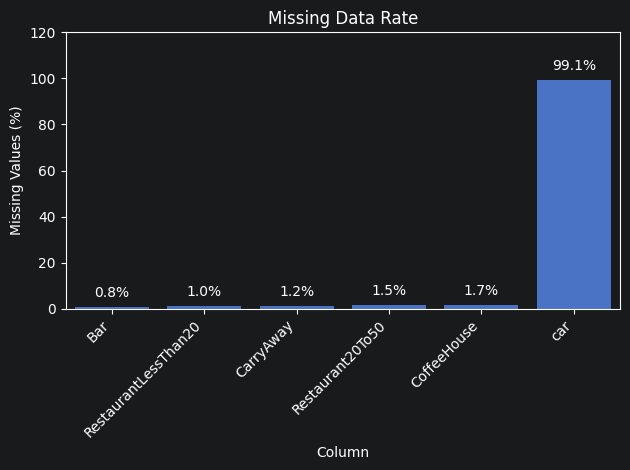

In [231]:
# Check missing values
missing_pct = data_without_duplicates.isnull().mean() * 100
missing_pct = missing_pct[missing_pct > 0].sort_values()

missing_df = missing_pct.reset_index()
missing_df.columns = ['column', 'missing_pct']

ax = sns.barplot(data=missing_df, x='column', y='missing_pct', legend=False)
ax.bar_label(ax.containers[0], fmt='%.1f%%', padding=5)
ax.set_ylim(0, 120) # Increase size of the main square box so the % doesn't overlap the main square container.
plt.title('Missing Data Rate')
plt.xlabel('Column')
plt.ylabel('Missing Values (%)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [232]:
# Based on the percentage of null rows, we will remove the entire car column and drop the null rows on (Bar, RestaurantLessThan20, CarryAway and Restaurant20To50)
cleaned_data = data_without_duplicates.drop(columns=['car'])
cleaned_data = cleaned_data.dropna()

In [233]:
missing_count = cleaned_data.isnull().sum()
print("Missing values remaining: ", missing_count.sum(), "rows")

Missing values remaining:  0 rows


4. What proportion of the total observations chose to accept the coupon?



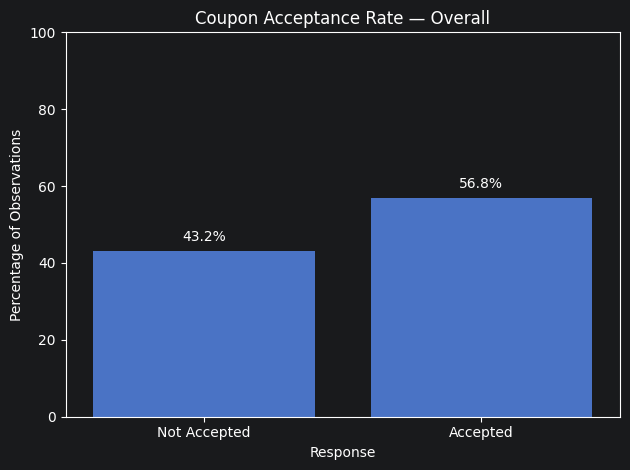

In [234]:
# The distribution of observations who accepted the coupon is based on the Y column, to visualize it, we can plot a bar chart
accept_df = cleaned_data['Y'].value_counts(normalize=True).sort_index().mul(100).reset_index()
accept_df.columns = ['accepted', 'percentage']
accept_df['accepted'] = accept_df['accepted'].map({0: 'Not Accepted', 1: 'Accepted'})

ax = sns.barplot(data=accept_df, x='accepted', y='percentage', legend=False)
ax.bar_label(ax.containers[0], fmt='%.1f%%', padding=5)
ax.set_ylim(0, 100) # Increase size of the main square box so the % doesn't overlap the main square container.
plt.title('Coupon Acceptance Rate — Overall')
plt.xlabel('Response')
plt.ylabel('Percentage of Observations')
plt.tight_layout()
plt.show()

Based on the chart above, 56.8% of the total observations chose to accept the coupon.

5. Use a bar plot to visualize the `coupon` column.

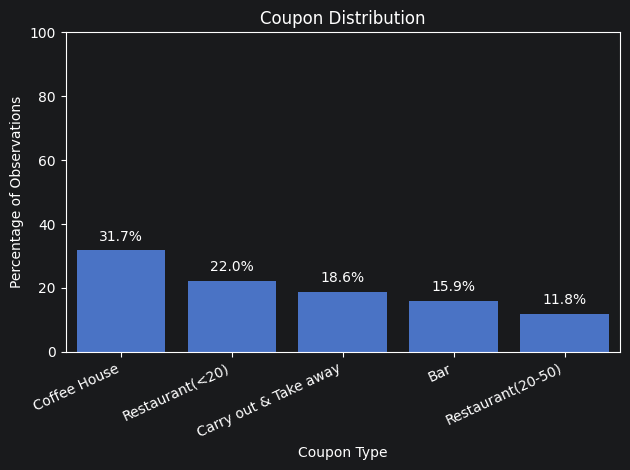

In [235]:
coupon_df = cleaned_data['coupon'].value_counts(normalize=True).mul(100).reset_index()
coupon_df.columns = ['coupon', 'percentage']

ax = sns.barplot(data=coupon_df, x='coupon', y='percentage', legend=False)
ax.bar_label(ax.containers[0], fmt='%.1f%%', padding=5)
ax.set_ylim(0, 100) # Increase size of the main square box so the % doesn't overlap the main square container.
plt.title('Coupon Distribution')
plt.xlabel('Coupon Type')
plt.ylabel('Percentage of Observations')
plt.xticks(rotation=25, ha='right')
plt.tight_layout()
plt.show()

6. Use a histogram to visualize the temperature column.

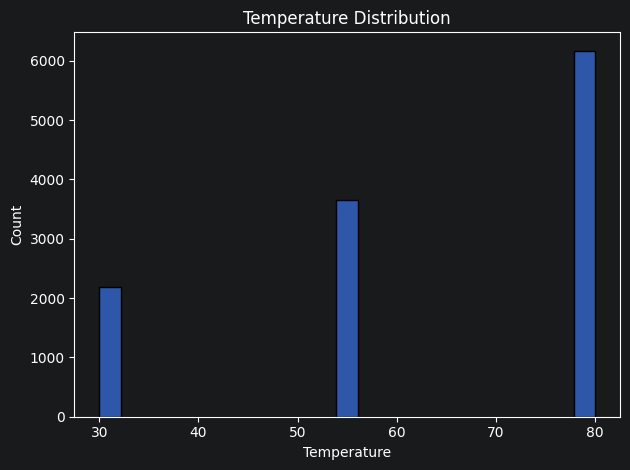

In [236]:
sns.histplot(data=cleaned_data, x='temperature')
plt.title('Temperature Distribution')
plt.xlabel('Temperature')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

**Investigating the Bar Coupons**

Now, we will lead you through an exploration of just the bar related coupons.  

1. Create a new `DataFrame` that contains just the bar coupons.


In [237]:
bar_df = cleaned_data[cleaned_data["coupon"] == "Bar"]
bar_df

,destination,passanger,weather,temperature,time,coupon,expiration,gender,age,maritalStatus,...,CoffeeHouse,CarryAway,RestaurantLessThan20,Restaurant20To50,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Y
24,No Urgent Place,Friend(s),Sunny,80,10AM,Bar,1d,Male,21,Single,...,less1,4~8,4~8,less1,1,0,0,0,1,1
35,Home,Alone,Sunny,55,6PM,Bar,1d,Male,21,Single,...,less1,4~8,4~8,less1,1,0,0,1,0,1
39,Work,Alone,Sunny,55,7AM,Bar,1d,Male,21,Single,...,less1,4~8,4~8,less1,1,1,1,0,1,1
46,No Urgent Place,Friend(s),Sunny,80,10AM,Bar,1d,Male,46,Single,...,4~8,1~3,1~3,never,1,0,0,0,1,0
57,Home,Alone,Sunny,55,6PM,Bar,1d,Male,46,Single,...,4~8,1~3,1~3,never,1,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12663,No Urgent Place,Friend(s),Sunny,80,10PM,Bar,1d,Male,26,Single,...,never,1~3,4~8,1~3,1,1,0,0,1,0
12664,No Urgent Place,Friend(s),Sunny,55,10PM,Bar,2h,Male,26,Single,...,never,1~3,4~8,1~3,1,1,0,0,1,0
12667,No Urgent Place,Alone,Rainy,55,10AM,Bar,1d,Male,26,Single,...,never,1~3,4~8,1~3,1,1,0,0,1,0
12670,No Urgent Place,Partner,Rainy,55,6PM,Bar,2h,Male,26,Single,...,never,1~3,4~8,1~3,1,1,0,0,1,0


2. What proportion of bar coupons were accepted?


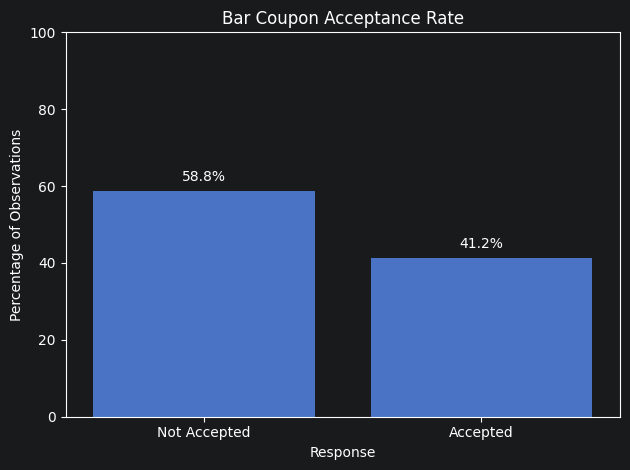

In [238]:
bar_accept_df = bar_df['Y'].value_counts(normalize=True).sort_index().mul(100).reset_index()
bar_accept_df.columns = ['accepted', 'percentage']
bar_accept_df['accepted'] = bar_accept_df['accepted'].map({0: 'Not Accepted', 1: 'Accepted'})

ax= sns.barplot(data=bar_accept_df, x='accepted', y='percentage', legend=False)
ax.bar_label(ax.containers[0], fmt='%.1f%%', padding=5)
ax.set_ylim(0, 100) # Increase size of the main square box so the % doesn't overlap the main square container.
plt.title('Bar Coupon Acceptance Rate')
plt.xlabel('Response')
plt.ylabel('Percentage of Observations')
plt.tight_layout()
plt.show()

Based on the chart above, 41.2% of the total observations chose to accept a bar coupon.

3. Compare the acceptance rate between those who went to a bar 3 or fewer times a month to those who went more.


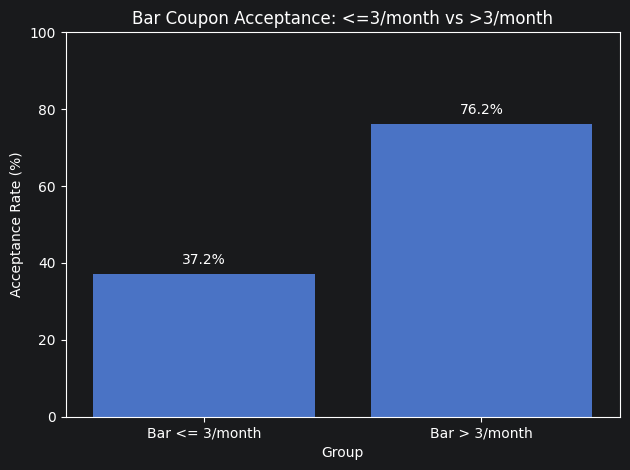

In [239]:
three_or_fewer = ['never', 'less1', '1~3']
more_than_three = ['4~8', 'gt8']

rates = pd.DataFrame({
    'group': ['Bar <= 3/month', 'Bar > 3/month'],
    'acceptance_rate': [
        bar_df.query('Bar in @three_or_fewer')['Y'].mean() * 100,
        bar_df.query('Bar in @more_than_three')['Y'].mean() * 100,
    ]
})

ax = sns.barplot(data=rates, x='group', y='acceptance_rate', legend=False)
ax.bar_label(ax.containers[0], fmt='%.1f%%', padding=5)
ax.set_ylim(0, 100) # Increase size of the main square box so the % doesn't overlap the main square container.
plt.title('Bar Coupon Acceptance: <=3/month vs >3/month')
plt.xlabel('Group')
plt.ylabel('Acceptance Rate (%)')
plt.tight_layout()
plt.show()

4. Compare the acceptance rate between drivers who go to a bar more than once a month and are over the age of 25 to the all others.  Is there a difference?


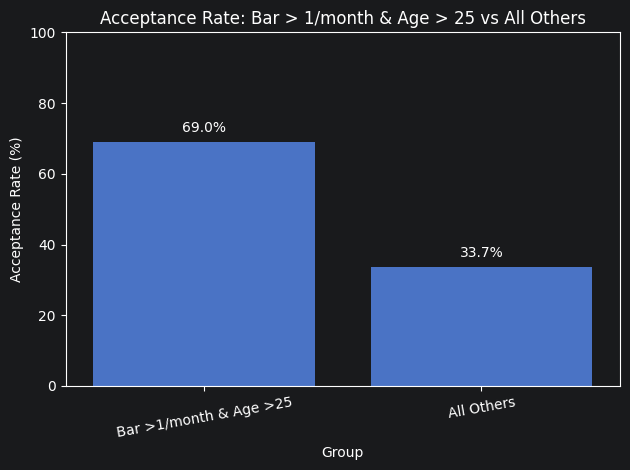

In [240]:
bar_visits_selection = ['1~3', '4~8', 'gt8']
age_selection = ['26','31','36','41','46','50plus']

group1 = bar_df.query('Bar in @bar_visits_selection & age in @age_selection')
group2 = bar_df.drop(group1.index)

rates = pd.DataFrame({
    'group': ['Bar >1/month & Age >25', 'All Others'],
    'acceptance_rate': [group1['Y'].mean() * 100, group2['Y'].mean() * 100]
})

ax = sns.barplot(data=rates, x='group', y='acceptance_rate', legend=False)
ax.bar_label(ax.containers[0], fmt='%.1f%%', padding=5)
ax.set_ylim(0, 100) # Increase size of the main square box so the % doesn't overlap the main square container.
plt.title('Acceptance Rate: Bar > 1/month & Age > 25 vs All Others')
plt.xlabel('Group')
plt.ylabel('Acceptance Rate (%)')
plt.xticks(rotation=10)
plt.tight_layout()
plt.show()

5. Use the same process to compare the acceptance rate between drivers who go to bars more than once a month and had passengers that were not a kid and had occupations other than farming, fishing, or forestry.


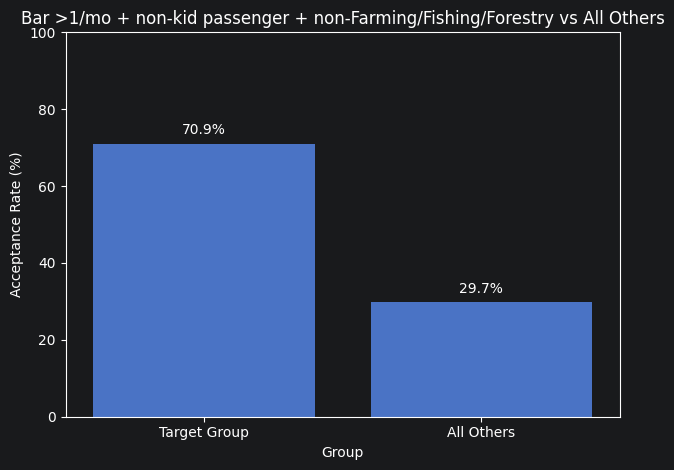

In [241]:
bar_visits_selection = ['1~3', '4~8', 'gt8']
non_kid_passengers = ['Alone', 'Friend(s)', 'Partner']
had_occupation_different_from = ['Farming Fishing & Forestry']

group1 = bar_df.query("Bar in @bar_visits_selection & passanger in @non_kid_passengers & occupation not in @had_occupation_different_from")
group2 = bar_df.drop(group1.index)

rates = pd.DataFrame({
    'group': ['Target Group', 'All Others'],
    'acceptance_rate': [group1['Y'].mean() * 100, group2['Y'].mean() * 100]
})

ax = sns.barplot(data=rates, x='group', y='acceptance_rate', legend=False)
ax.bar_label(ax.containers[0], fmt='%.1f%%', padding=5)
ax.set_ylim(0, 100) # Increase size of the main square box so the % doesn't overlap the main square container.
plt.title('Bar >1/mo + non-kid passenger + non-Farming/Fishing/Forestry vs All Others')
plt.xlabel('Group')
plt.ylabel('Acceptance Rate (%)')
plt.tight_layout()
plt.show()

6. Compare the acceptance rates between those drivers who:

- go to bars more than once a month, had passengers that were not a kid, and were not widowed *OR*
- go to bars more than once a month and are under the age of 30 *OR*
- go to cheap restaurants more than 4 times a month and income is less than 50K.



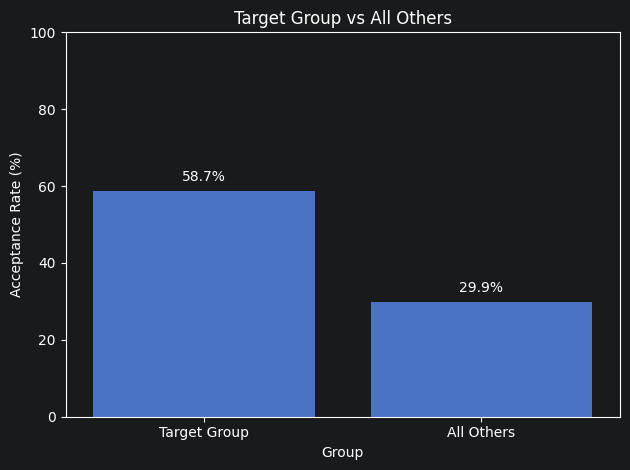

In [242]:
bar_visits_selection = ['1~3', '4~8', 'gt8'] # bar column
non_kid_passengers = ['Alone', 'Friend(s)', 'Partner'] # passenger column
widowed = ['Widowed'] # marital status column
under_30_age = ['below21', '21', '26'] # age column - The question state under the age 30 but the 26 age covers from 26 to 30, here we are doing an inclusive consideration.
cheap_restaurants = ['4~8', 'gt8']  # RestaurantLessThan20 column
income_less_than_50K = ['Less than $12500', '$12500 - $24999', '$25000 - $37499', '$37500 - $49999']

# Group 1: Go to bars more than once a month, had passengers that were not a kid, and were not widowed *OR*
#   Go to bars more than once a month and are under the age of 30 *OR*
#   Go to cheap restaurants more than 4 times a month and income is less than 50K.
target_group = bar_df.query("(Bar in @bar_visits_selection & passanger in @non_kid_passengers & maritalStatus not in @widowed) | (Bar in @bar_visits_selection & age in @under_30_age) | (RestaurantLessThan20 in @cheap_restaurants & income in @income_less_than_50K)")

# Group 2 - All others
all_others = bar_df.drop(target_group.index)

rates = pd.DataFrame({
    'group': ['Target Group', 'All Others'],
    'acceptance_rate': [target_group['Y'].mean() * 100, all_others['Y'].mean() * 100]
})

ax = sns.barplot(data=rates, x='group', y='acceptance_rate', legend=False)
ax.bar_label(ax.containers[0], fmt='%.1f%%', padding=5)
ax.set_ylim(0, 100) # Increase size of the main square box so the % doesn't overlap the main square container.
plt.title('Target Group vs All Others')
plt.xlabel('Group')
plt.ylabel('Acceptance Rate (%)')
plt.tight_layout()
plt.show()

7.  Based on these observations, what do you hypothesize about drivers who accepted the bar coupons?

In the general population, bar coupons are more likely to be rejected (58.8% vs 41.2%).

However, drivers who go to a bar one or more times per month are significantly more likely to accept them, with an acceptance rate nearly double that of the rest.

We can hypothesize that to increase bar coupon acceptance rates, the ideal target population is drivers who visit bars more than 3 times a month.

### Independent Investigation

Using the bar coupon example as motivation, you are to explore one of the other coupon groups and try to determine the characteristics of passengers who accept the coupons.

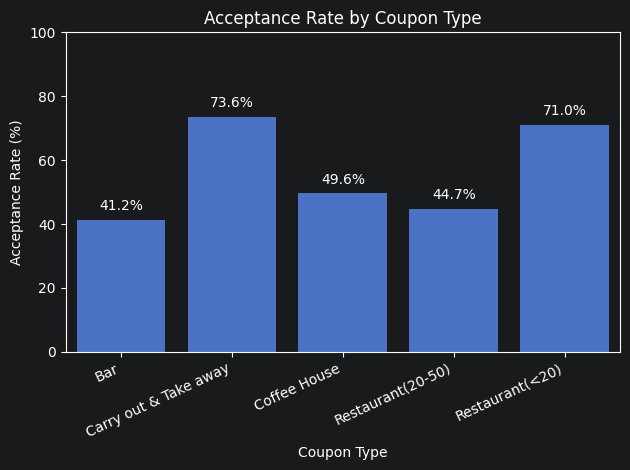

In [243]:
coupon_acceptance = cleaned_data.groupby('coupon', as_index=False)['Y'].mean()
coupon_acceptance['acceptance_rate'] = coupon_acceptance['Y'] * 100

ax = sns.barplot(data=coupon_acceptance, x='coupon', y='acceptance_rate', legend=False)
ax.bar_label(ax.containers[0], fmt='%.1f%%', padding=5)
ax.set_ylim(0, 100) # Increase size of the main square box so the % doesn't overlap the main square container.
plt.title('Acceptance Rate by Coupon Type')
plt.xlabel('Coupon Type')
plt.ylabel('Acceptance Rate (%)')
plt.xticks(rotation=25, ha='right')
plt.tight_layout()
plt.show()

### Idea

For each coupon type, we filtered the data to that coupon only and then we calculate the acceptance rate across the values of the other columns, such as time, age, destination, etc.

This process is repeated for each coupon type, at the end we will merge them and get the top 10 segments with the highest acceptance rate for each coupon type.

To avoid smallest subsets we set a threshold to 100 and filter out any segments with less than 100 observation, the number 100 was selected without any specific reasoning, it was chosen based on the assumption that smaller subsets might not be representative of the overall population and could lead to misleading results.

In [244]:
# Analyze acceptance rate per coupon type, type "Coffee House"
target = 'Coffee House'
sub = cleaned_data[cleaned_data['coupon'] == target]
features = [c for c in sub.columns if c not in {'Y', 'coupon'}]
threshold = 100 # Avoid tiny cohorts that can with large acceptance rates.

rows = []
for feature in features:
    acceptance_rate = sub.groupby(feature)['Y'].agg(['mean', 'count'])
    for value, row in acceptance_rate.iterrows():
        rows.append({'feature': feature, 'value': value, 'acceptance_rate': row['mean'] * 100, 'n': int(row['count'])})

coffee_df = pd.DataFrame(rows).sort_values('acceptance_rate', ascending=False)
coffee_df[coffee_df['n'] >= threshold].head(5)


,feature,value,acceptance_rate,n
83,CoffeeHouse,4~8,68.244576,507
29,age,below21,67.832168,143
84,CoffeeHouse,gt8,65.789474,342
82,CoffeeHouse,1~3,64.729064,1015
13,time,10AM,63.434579,856


In [245]:
# Analyze acceptance rate per coupon type, type "Carry out & Take away"
target = 'Carry out & Take away'
sub = cleaned_data[cleaned_data['coupon'] == target]
features = [c for c in sub.columns if c not in {'Y', 'coupon'}]
threshold = 100 # Avoid tiny cohorts that can with large acceptance rates.

rows = []
for feature in features:
    acceptance_rate = sub.groupby(feature)['Y'].agg(['mean', 'count'])
    for value, row in acceptance_rate.iterrows():
        rows.append({'feature': feature, 'value': value, 'acceptance_rate': row['mean'] * 100, 'n': int(row['count'])})

carry_out_coupons_dataframe = pd.DataFrame(rows).sort_values('acceptance_rate', ascending=False)
carry_out_coupons_dataframe[carry_out_coupons_dataframe['n'] >= threshold].head(5)


,feature,value,acceptance_rate,n
15,time,2PM,86.602871,209
37,education,Associates degree,83.248731,197
16,time,6PM,81.995134,411
0,destination,Home,79.126214,618
70,income,$25000 - $37499,78.711485,357


In [246]:
# Analyze acceptance rate per coupon type, type "Restaurant(<20)"
target = 'Restaurant(<20)'
sub = cleaned_data[cleaned_data['coupon'] == target]
features = [c for c in sub.columns if c not in {'Y', 'coupon'}]
threshold = 100 # Avoid tiny cohorts that can with large acceptance rates.

rows = []
for feature in features:
    acceptance_rate = sub.groupby(feature)['Y'].agg(['mean', 'count'])
    for value, row in acceptance_rate.iterrows():
        rows.append({'feature': feature, 'value': value, 'acceptance_rate': row['mean'] * 100, 'n': int(row['count'])})

restaurant_lt20_coupons_dataframe = pd.DataFrame(rows).sort_values('acceptance_rate', ascending=False)
restaurant_lt20_coupons_dataframe[restaurant_lt20_coupons_dataframe['n'] >= threshold].head(5)

,feature,value,acceptance_rate,n
18,expiration,1d,83.553142,1289
16,time,6PM,82.657343,715
15,time,2PM,81.487102,659
4,passanger,Friend(s),80.354880,789
64,occupation,Sales & Related,79.828326,233


In [247]:
# Analyze acceptance rate per coupon type, type "Restaurant(20-50)"
target = 'Restaurant(20-50)'
sub = cleaned_data[cleaned_data['coupon'] == target]
features = [c for c in sub.columns if c not in {'Y', 'coupon'}]
threshold = 100 # Avoid tiny cohorts that can with large acceptance rates.

rows = []
for feature in features:
    acceptance_rate = sub.groupby(feature)['Y'].agg(['mean', 'count'])
    for value, row in acceptance_rate.iterrows():
        rows.append({'feature': feature, 'value': value, 'acceptance_rate': row['mean'] * 100, 'n': int(row['count'])})

restaurant_20to50_coupons_dataframe = pd.DataFrame(rows).sort_values('acceptance_rate', ascending=False)
restaurant_20to50_coupons_dataframe[restaurant_20to50_coupons_dataframe['n'] >= threshold].head(5)


,feature,value,acceptance_rate,n
6,passanger,Partner,62.500000,136
13,time,10AM,60.747664,107
82,CoffeeHouse,1~3,55.124654,361
15,time,2PM,54.597701,174
48,occupation,Computer & Mathematical,53.374233,163


In [248]:
# Analyze acceptance rate per coupon type, type "Bar"
target = 'Bar'
sub = cleaned_data[cleaned_data['coupon'] == target]
features = [c for c in sub.columns if c not in {'Y', 'coupon'}]
threshold = 100 # Avoid tiny cohorts that can with large acceptance rates.

rows = []
for feature in features:
    acceptance_rate = sub.groupby(feature)['Y'].agg(['mean', 'count'])
    for value, row in acceptance_rate.iterrows():
        rows.append({'feature': feature, 'value': value, 'acceptance_rate': row['mean'] * 100, 'n': int(row['count'])})

bar_dataframe = pd.DataFrame(rows).sort_values('acceptance_rate', ascending=False)
bar_dataframe[bar_dataframe['n'] >= threshold].head(5)

,feature,value,acceptance_rate,n
78,Bar,4~8,77.551020,147
77,Bar,1~3,64.643799,379
98,Restaurant20To50,4~8,63.063063,111
4,passanger,Friend(s),56.645570,316
58,occupation,Management,55.769231,104


In [249]:
# Concat all dataframes together to sort them by acceptance rate
all_segments = pd.concat([
    coffee_df.assign(coupon='Coffee House'),
    carry_out_coupons_dataframe.assign(coupon='Carry out & Take away'),
    restaurant_lt20_coupons_dataframe.assign(coupon='Restaurant(<20)'),
    restaurant_20to50_coupons_dataframe.assign(coupon='Restaurant(20-50)'),
    bar_dataframe.assign(coupon='Bar'),
])

# Avoid tiny cohorts that can with large acceptance rates.
threshold = 100

# Drop segments with too few observations.
filtered = all_segments[all_segments['n'] >= threshold].copy() # Copy avoids a warning about "A value is trying to be set on a copy of a slice from a DataFrame"

(filtered
    .sort_values('acceptance_rate', ascending=False)
    .head(10))

,feature,value,acceptance_rate,n,coupon
15,time,2PM,86.602871,209,Carry out & Take away
18,expiration,1d,83.553142,1289,Restaurant(<20)
37,education,Associates degree,83.248731,197,Carry out & Take away
16,time,6PM,82.657343,715,Restaurant(<20)
16,time,6PM,81.995134,411,Carry out & Take away
15,time,2PM,81.487102,659,Restaurant(<20)
4,passanger,Friend(s),80.354880,789,Restaurant(<20)
64,occupation,Sales & Related,79.828326,233,Restaurant(<20)
1,destination,No Urgent Place,79.458795,1626,Restaurant(<20)
0,destination,Home,79.126214,618,Carry out & Take away


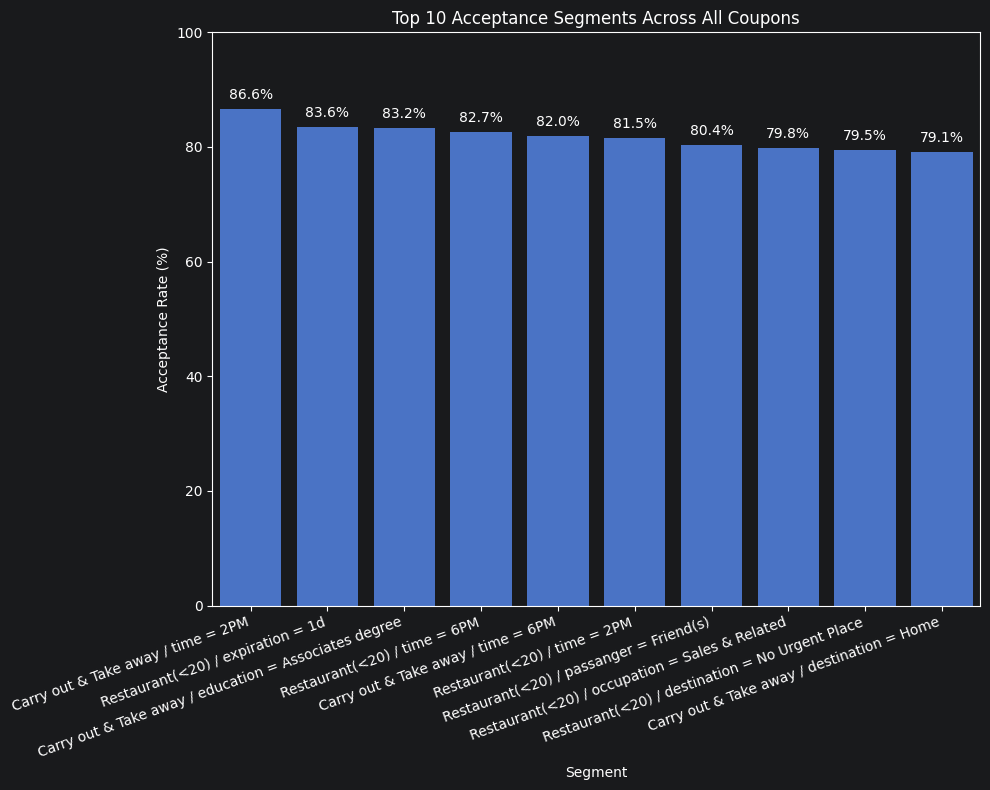

In [250]:
filtered['segment'] = filtered['coupon'] + ' / ' + filtered['feature'] + ' = ' + filtered['value'].astype(str)

top = filtered.sort_values('acceptance_rate', ascending=False).head(10)

plt.figure(figsize=(10, 8))
ax = sns.barplot(data=top, x='segment', y='acceptance_rate', legend=False)
ax.bar_label(ax.containers[0], fmt='%.1f%%', padding=5)
ax.set_ylim(0, 100) # Increase size of the main square box so the % doesn't overlap the main square container.
plt.title('Top 10 Acceptance Segments Across All Coupons')
plt.xlabel('Segment')
plt.ylabel('Acceptance Rate (%)')
plt.xticks(rotation=20, ha='right')

plt.tight_layout()
plt.show()

As expected, drivers are more likely to accept coupons for food (Restaurant <$20 and Carry out) around lunch
(2PM) and dinner (6PM), where acceptance rates are near 80%.

For Bar coupons specifically, the deeper analysis showed that drivers who are already regular customers are more
likely to accept them, but even then, the acceptance rate is still below Restaurant coupons at lunch or dinner.